## Business Problem

HealthConnect Clinic aims to reduce missed appointments, improve appointment attendance, optimise appointment slot utilisation, and enhance patient support. My role is to analyse appointment data to identify factors associated with appointment attendance and no-shows.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 ## Data Loading

In [4]:
#loading the dataset

df = pd.read_csv("../data/HealthConnect_Appointment_Data.csv")

df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## Data Inspection + Cleaning

In [7]:
df.shape

(5000, 18)

In [8]:
df.columns

Index(['appointment_id', 'patient_id', 'gender', 'age', 'age_group',
       'appointment_type', 'booking_date', 'appointment_date',
       'appointment_day', 'appointment_time', 'booking_lead_days',
       'previous_appointments', 'previous_no_shows', 'reminder_sent',
       'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes',
       'appointment_outcome'],
      dtype='object')

In [16]:
#to see the data types of our columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

Booking and appointment date columns should be of the date type, not objects(strings).

In [10]:
df.describe(include='object')

,appointment_id,patient_id,gender,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,reminder_sent,reminder_channel,appointment_outcome
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,3634,5000
unique,5000,1696,3,6,4,593,545,7,3,2,3,3
top,HC-00001,P-1399,Female,65+,General Consultation,8/24/2025,3/14/2026,Wednesday,Morning,Yes,SMS,No-Show
freq,1,9,2488,1241,2086,20,18,737,2227,3634,2000,2423


In [13]:
#makimg a table to see how many missing values we have in each column
missing = df.isnull().sum()

missing = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": round((missing/len(df))*100,2)
})

missing

,Missing Values,Percentage
appointment_id,0,0.00
patient_id,0,0.00
gender,0,0.00
age,0,0.00
age_group,0,0.00
appointment_type,0,0.00
booking_date,0,0.00
appointment_date,0,0.00
appointment_day,0,0.00
appointment_time,0,0.00


In [27]:
pd.crosstab(df['reminder_sent'], df['reminder_channel'])

reminder_channel,Email,SMS,WhatsApp
reminder_sent,,,
Yes,533,2000,1101


About 27% of the data is missing values in teh reminder channel column. And just under 2% of thhe data is missing valuees for waiting time and distance to clinic.  As for the wait time and distance to clinic, i think we can continue because it is less than 2% of the data thats missing this info. 

In [26]:
df[['reminder_sent', 'reminder_channel']].head()

,reminder_sent,reminder_channel
0,Yes,WhatsApp
1,Yes,SMS
2,Yes,SMS
3,Yes,SMS
4,Yes,Email


In [14]:
#checking for duplicates

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [17]:
#changing booking date and appintment date datatypes
df['booking_date'] = pd.to_datetime(df['booking_date'])

df['appointment_date'] = pd.to_datetime(df['appointment_date'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   appointment_id         5000 non-null   object        
 1   patient_id             5000 non-null   object        
 2   gender                 5000 non-null   object        
 3   age                    5000 non-null   int64         
 4   age_group              5000 non-null   object        
 5   appointment_type       5000 non-null   object        
 6   booking_date           5000 non-null   datetime64[ns]
 7   appointment_date       5000 non-null   datetime64[ns]
 8   appointment_day        5000 non-null   object        
 9   appointment_time       5000 non-null   object        
 10  booking_lead_days      5000 non-null   int64         
 11  previous_appointments  5000 non-null   int64         
 12  previous_no_shows      5000 non-null   int64         
 13  rem

## Exploratory Data Analysis

#### Appointment Outcome Distribution

In [19]:
#Seeing the number of attended, unattended, and cancelled appointments

df['appointment_outcome'].value_counts()


appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

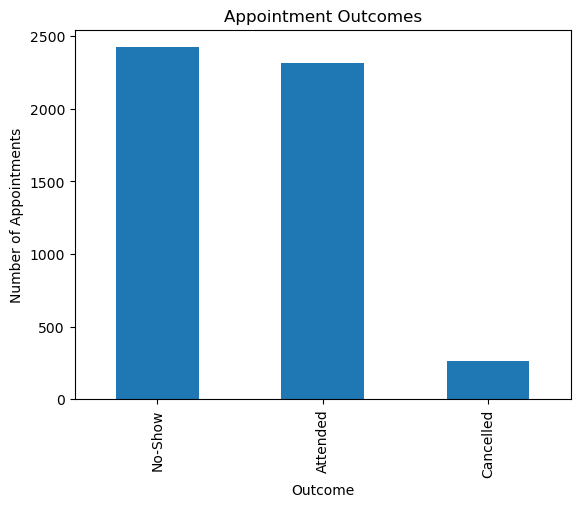

In [20]:
df['appointment_outcome'].value_counts().plot(kind='bar')

plt.title("Appointment Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Appointments")

plt.show()

Appointment attendance and no-shows occur in similar proportions, with no-shows slightly exceeding attended appointments. Approximately 5% of appointments were cancelled. This suggests that appointment non-attendance is a significant operational issue for HealthConnect Clinic and supports the project's objective of understanding factors associated with missed appointments.

#### Gender Distribution

In [21]:
df['gender'].value_counts()

gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

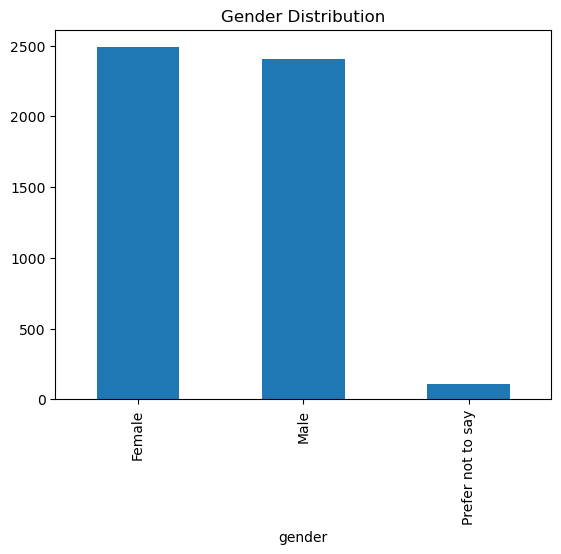

In [22]:
df['gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")

plt.show()

The male and female genders are almost equally distributed. Indicating that the dataset is well balanced with respect to gender.

#### Appointment Type

In [24]:
df['appointment_type'].value_counts()

appointment_type
General Consultation       2086
Follow-up                  1421
Specialist Consultation     900
Diagnostic Test             593
Name: count, dtype: int64

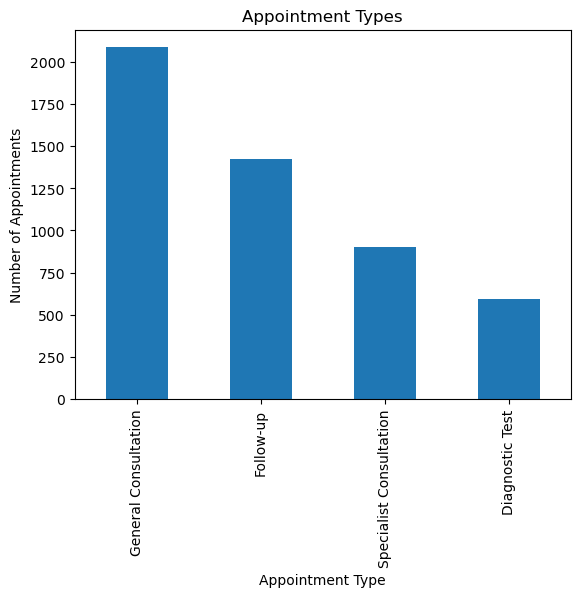

In [25]:
df['appointment_type'].value_counts().plot(kind='bar')

plt.title("Appointment Types")
plt.xlabel("Appointment Type")
plt.ylabel("Number of Appointments")

plt.show()

The most common appointment type is General Consultation with just over 2000 appointments falling under this.
Diagnostic Tests are the least common, with fewer than 600 appointments.



#### Reminder Information

In [29]:
df['reminder_sent'].value_counts()

reminder_sent
Yes    3634
No     1366
Name: count, dtype: int64

In [30]:
df['reminder_channel'].value_counts()

reminder_channel
SMS         2000
WhatsApp    1101
Email        533
Name: count, dtype: int64

We have 3264 reminders sent and 1366 have not been sent. 
2000 SMSs, 1101 WhatsApps and 533 E-mails all add up to 3634 so 
that means the missing values under reminder_channel 
signify the reminders that were not able to be sent.

In [ ]:
A great number of appointments do not have prior no-shows. 
About 1500 appointments have had 1 noo show befoore.
And the number keeps decreasing.


#### Does sending of reminders affect appintment outcome? 

In [36]:
pd.crosstab(df['reminder_sent'], df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,583,81,702
Yes,1731,182,1721


#### Is there a relatioonship between appointmeent type and appointment outcome?


In [37]:
pd.crosstab(df['appointment_type'], df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
appointment_type,,,
Diagnostic Test,272,26,295
Follow-up,616,77,728
General Consultation,1007,106,973
Specialist Consultation,419,54,427


General Consultation has the highest number of attended appointments, cancellations, and no-shows. This is expected because it is the most common appointment type in the dataset.

In several appointment types, no-shows slightly exceed attendances, whereas General Consultation is the only appointment type where attendances are higher than no-shows.

#### Does gender affect outcome?

In [38]:
pd.crosstab(df['gender'], df['appointment_outcome'])


appointment_outcome,Attended,Cancelled,No-Show
gender,,,
Female,1153,130,1205
Male,1103,130,1171
Prefer not to say,58,3,47


There is no correlation between gender and outcome.
Though from the table we see that women are slightly more likely to not show up compared to men. 

#### Age Group vs Outcome

In [44]:
pd.crosstab(
    df['age_group'], 
    df['appointment_outcome'],
    normalize = 'index'
).mul(100).round(1)


appointment_outcome,Attended,Cancelled,No-Show
age_group,,,
18-24,45.6,4.3,50.2
25-34,45.1,4.2,50.7
35-44,45.7,6.0,48.4
45-54,46.0,5.9,48.0
55-64,45.0,4.2,50.7
65+,48.8,6.1,45.1


Initial Findings

• The dataset contains 5,000 appointment records.
• A small number of missing values were identified.
• The dataset appears suitable for further analysis after basic cleaning.
• Variables such as previous no-shows, reminder status, waiting time and distance to the clinic appear likely to influence appointment attendance.
• Further analysis in Week 5 will explore these relationships in greater detail.

# Week 5 – Review of Week 4 Foundation

In Week 4, I assessed the quality of the appointment dataset, explored the available variables, identified business questions and proposed KPIs that would guide the analysis.

Data preparation completed during Week 4 included checking data types, identifying missing values, inspecting duplicates, reviewing variable consistency and converting date columns where appropriate. No changes were made to the original dataset. Any future transformations will be performed on a copy of the data.

#### Assumptions
- The dataset accurately reflects the clinic's real appointment records.
- Appointment outcomes were correctly recorded.
- Missing reminder channel values may indicate that reminders were not sent.
- Cancellations and no-shows both mean an empty slot, but they're not really the same problem. A cancellation comes with warning, so the clinic has a chance to fill it or offer it to someone else. A no-show doesn't. That's why this project is focused specifically on no-shows rather than treating all missed appointments the same way. If later analysis does lump cancellations and no-shows together into one "missed appointment" bucket, that distinction is worth keeping in mind when reading the results.

#### Limitations
- This is a fictional dataset, so it may not capture every nuance of a real clinic.
- Outside factors like weather, transport issues, or a patient's health on the day aren't captured here.
- There's also a handful of factors we simply don't have data on, things like appointment cost, staffing levels on a given day, how busy the clinic was, or patients' socioeconomic background. These factors may also influence appointment attendance but cannot be assessed using the available data.



#### Week 5 Objective

This week focuses on moving beyond exploration by analysing relationships in the data, calculating KPIs, producing business insights and creating an initial dashboard.

##### Previous No-Shows

In [8]:
pd.crosstab(
    df['previous_no_shows'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).round(1)

appointment_outcome,Attended,Cancelled,No-Show
previous_no_shows,,,
0,50.5,6.0,43.5
1,42.2,4.3,53.5
2,36.3,4.3,59.4
3,29.5,2.6,67.9
4,33.3,0.0,66.7
5,0.0,0.0,100.0


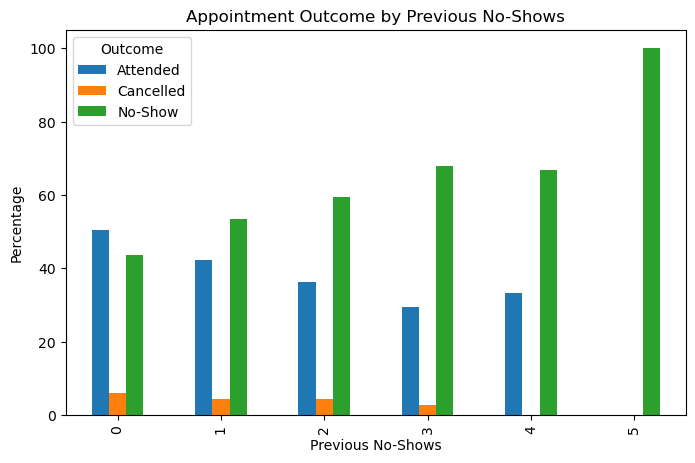

In [7]:
pd.crosstab(
    df['previous_no_shows'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).plot(kind='bar', figsize=(8,5))

plt.title("Appointment Outcome by Previous No-Shows")
plt.ylabel("Percentage")
plt.xlabel("Previous No-Shows")
plt.legend(title="Outcome")
plt.show()

Patients who have previously missed appointments seem to be more likely to miss subsequent appointments. So previous appointment history appears to be one of the strongest indicators of future attendance. 

Patients with no previous no-shows had a no-show rate of 43.5%, whereas patients with three previous no-shows missed nearly 68% of their appointments. This suggests that patients with a history of missed appointments represent a high-risk group and could benefit from targeted reminder strategies or additional follow-up before future appointments.

##### Reminder Sent vs Appointment Outcome

In [9]:
pd.crosstab(
    df['reminder_sent'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).round(1)

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,42.7,5.9,51.4
Yes,47.6,5.0,47.4


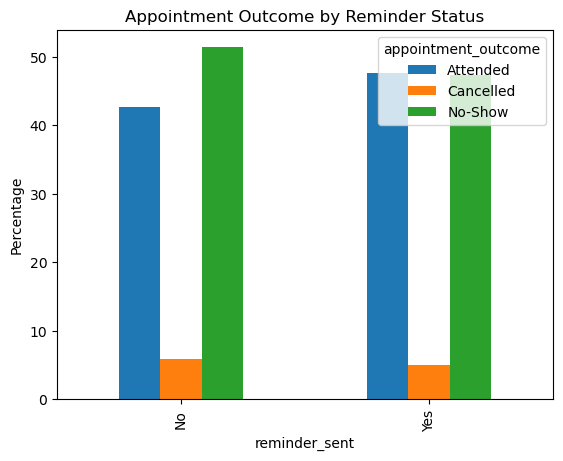

In [10]:
pd.crosstab(
    df['reminder_sent'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).plot(kind='bar')

plt.title("Appointment Outcome by Reminder Status")
plt.ylabel("Percentage")

plt.show()

Slightly greater percentage of attendance (47.6%) from those who had a reminder sent to them than thoose who had no reminder sent to them (42.7%). Greater percentage of no shows (51.4%) from those who had no reminder sent to them than those who had a reminder sent (47.4%).

Although reminders do not eliminate missed appointments, they appear to have a positive influence on attendance and may be an effective strategy for reducing no-shows.

##### Booking Lead Days (number of days betweeen booking appointmeent and attending appointment)

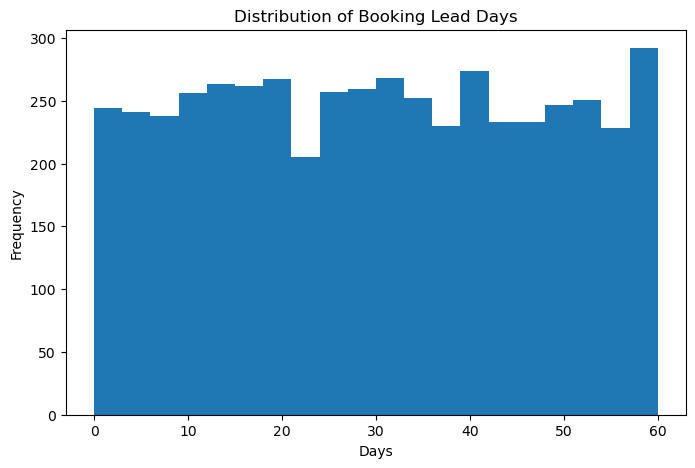

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df['booking_lead_days'], bins=20)

plt.title("Distribution of Booking Lead Days")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

Booking lead times are concentrated around 40 and 60 days, suggesting that many appointments are scheduled several weeks in advance. Further analysis is required to determine whether longer booking lead times are associated with higher no-show rates.

In [25]:
df.groupby("appointment_outcome")["booking_lead_days"].median()

appointment_outcome
Attended     23.0
Cancelled    30.0
No-Show      37.0
Name: booking_lead_days, dtype: float64

Froom this we can see that patients who missed their appointments tended to book much further in advance than those who attended.

A no-show appointment was typically booked 14 days earlier than an attended appointment (37 vs 23 days).

This suggests that longer booking lead times may contribute to forgetfulness, changing schedules, or reduced commitment to the appointment. The clinic could consider implementing additional reminders or confirmation requests for appointments booked several weeks in advance.

##### Waiting Time by Outcome

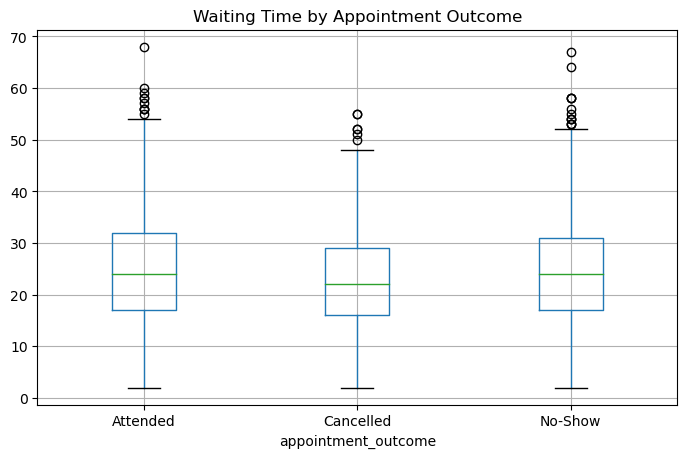

In [13]:
df.boxplot(
    column='waiting_time_minutes',
    by='appointment_outcome',
    figsize=(8,5)
)

plt.suptitle("")
plt.title("Waiting Time by Appointment Outcome")

plt.show()

The distribution of waiting times is very similar between Attended and no-Show appointment outcomes. Median waiting times differ by about one minute between attended appointments and no-shows, suggesting that waiting time alone may not be a strong factor influencing appointment attendance.

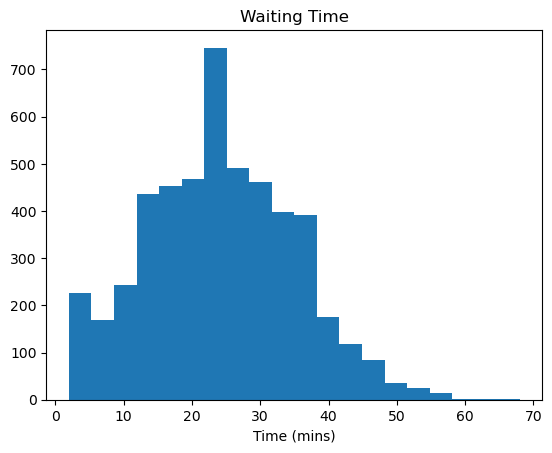

In [14]:
plt.hist(df['waiting_time_minutes'], bins=20)

plt.title("Waiting Time")
plt.xlabel("Time (mins)")

plt.show()

Waiting times are concentrated around 30 minutes, with approximately 700 appointments experiencing a waiting time of around 30 minutes. This suggests that a 30-minute wait is common at the clinic.Waiting times are concentrated around 30 minutes, with approximately 700 appointments experiencing a waiting time of around 30 minutes. This suggests that a 30-minute wait is common at the clinic.

##### Distance by Outcome

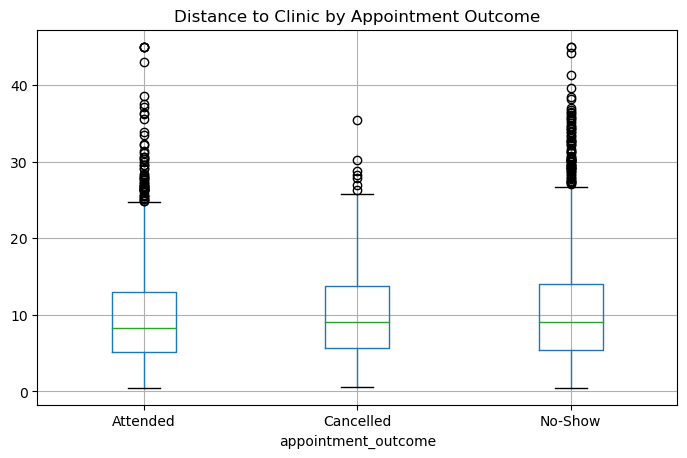

In [15]:
df.boxplot(
    column='distance_to_clinic_km',
    by='appointment_outcome',
    figsize=(8,5)
)

plt.suptitle("")
plt.title("Distance to Clinic by Appointment Outcome")

plt.show()

The distribution of distance to clinic is very similar between all appointment outcomes. Median distances between the appointment outcomes do not really differ at all. This also suggests that distance to clinic alone may not be a strong factor influencing appointment attendance.

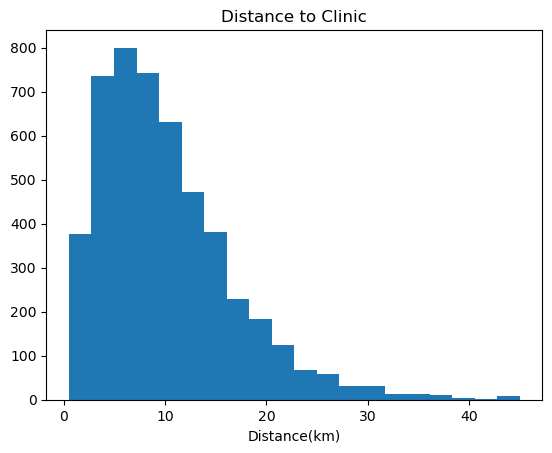

In [16]:
plt.hist(df['distance_to_clinic_km'], bins=20)

plt.title("Distance to Clinic")
plt.xlabel("Distance(km)")

plt.show()

The distance to the clinic is not evenly distributed. Approximately 800 appointments involve patients living around 10 km from the clinic, making this the most common travel distance in the dataset.

##### Age by Outcome

In [17]:
df.groupby('appointment_outcome')['age'].mean()

appointment_outcome
Attended     49.247623
Cancelled    50.152091
No-Show      48.215023
Name: age, dtype: float64

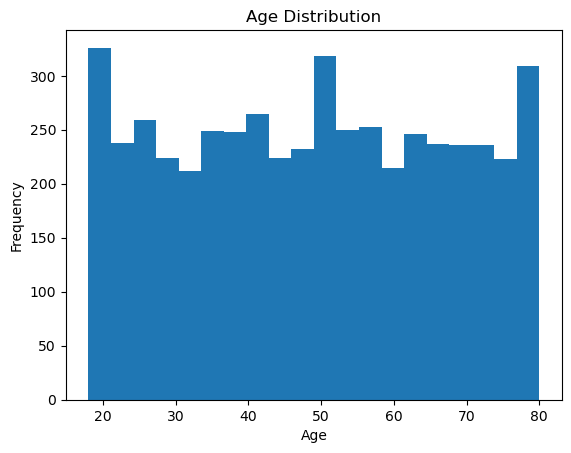

In [18]:
plt.hist(df['age'], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

The age distribution shows several peaks, particularly among patients in their twenties, around age fifty, and in the late seventies to early eighties. Further analysis will determine whether these age groups exhibit different appointment attendance patterns.

##### Appointment Type by Outcome

In [22]:
appointment_pct = pd.crosstab(
    df['appointment_type'],
    df['appointment_outcome'],
    normalize='index'
).mul(100)

appointment_pct['No-Show'].sort_values(ascending=False)

appointment_type
Follow-up                  51.231527
Diagnostic Test            49.747049
Specialist Consultation    47.444444
General Consultation       46.644295
Name: No-Show, dtype: float64

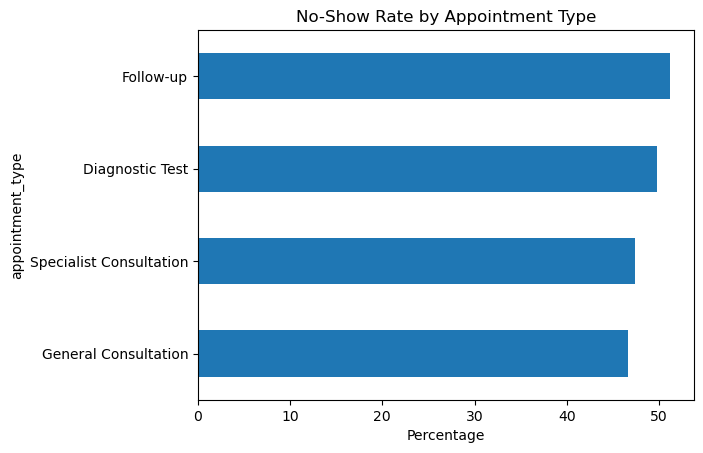

In [24]:
appointment_pct['No-Show'].sort_values().plot(kind='barh')

plt.title("No-Show Rate by Appointment Type")
plt.xlabel("Percentage")

plt.show()

No-Shows accoount for 51% of Follow-up appointments, with the lowest being 46% for General consultations. We can see that no shows accoount for almost up to half of all appoointment types. Showing that  missed appointments are a widespread issue rather than being limited to a specific service.

##### Average Summary Stats

In [27]:
df.groupby('appointment_outcome')[[
    'age',
    'booking_lead_days',
    'waiting_time_minutes',
    'distance_to_clinic_km'
]].mean().round(1)

,age,booking_lead_days,waiting_time_minutes,distance_to_clinic_km
appointment_outcome,,,,
Attended,49.2,24.5,24.3,9.7
Cancelled,50.2,29.6,23.2,10.1
No-Show,48.2,34.5,24.2,10.5


Patients who missed their appointments tended to book significantly further in advance than those who attended. This suggests that longer booking lead times may increase the likelihood of missed appointments, possibly because patients forget, their schedules change, or the appointment becomes less of a priority. HealthConnect could consider implementing additional reminder or confirmation strategies for appointments booked well in advance.

Average waiting times were almost identical across appointment outcomes, suggesting that waiting time alone is unlikely to be a major factor influencing appointment attendance in this dataset.

Patients who missed appointments travelled only slightly further to the clinic on average than those who attended. The small difference suggests that travel distance may have only a limited influence on appointment attendance.

The average patient age was similar across all appointment outcomes, indicating that age alone does not appear to strongly influence appointment attendance.